In [ ]:
#importing libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, InputLayer
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
#setting dataset path, each folder containing 2 subfolder(fractured n nonfractured)
data_dir = "/content/drive/MyDrive/Bone_Fracture_Binary_Classification"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val") #val set used to evaluate model before testing
test_dir = os.path.join(data_dir, "test")


#load dataset
datagen = ImageDataGenerator(rescale=1./255) #rescaling pixels from 0-255 to 0-1

train_ds = datagen.flow_from_directory(
    train_dir,
    target_size=(96, 96),   #resize img to 96x96
    batch_size=32,          #32 images loaded per step
    class_mode='binary',    #binary output, fractured/nonfractured
    shuffle=True            #shuffling to avoid overfitting
)

val_ds = datagen.flow_from_directory(
    val_dir,
    target_size=(96, 96),
    batch_size=32,
    class_mode='binary',
    shuffle=False           #no shuffle for validation
)

test_ds = datagen.flow_from_directory(
    test_dir,
    target_size=(96, 96),
    batch_size=32,
    class_mode='binary',
    shuffle=False           #no shuffle for validation
)


Found 9483 images belonging to 2 classes.
Found 829 images belonging to 2 classes.
Found 506 images belonging to 2 classes.


In [ ]:
#checking label mapping for predictions later
print(train_ds.class_indices)
#fractured will be 0, nonfractured will be 1

{'fractured': 0, 'nonfractured': 1}


In [ ]:
#preprocessing: counting number of images in each class to make sure dataset is balanced
import os

#train set
fractured_path = os.path.join(train_dir, 'fractured')
nonfractured_path = os.path.join(train_dir, 'nonfractured')
num_fractured = len(os.listdir(fractured_path))
num_nonfractured = len(os.listdir(nonfractured_path))

#val set
fractured_path2 = os.path.join(val_dir, 'fractured')
nonfractured_path2 = os.path.join(val_dir, 'nonfractured')
num_fractured2 = len(os.listdir(fractured_path2))
num_nonfractured2 = len(os.listdir(nonfractured_path2))

#test set
fractured_path3 = os.path.join(test_dir, 'fractured')
nonfractured_path3 = os.path.join(test_dir, 'nonfractured')
num_fractured3 = len(os.listdir(fractured_path3))
num_nonfractured3 = len(os.listdir(nonfractured_path3))

print("Train:")
print("Fractured:", num_fractured)
print("Non-Fractured:", num_nonfractured)

print("Val:")
print("Fractured:", num_fractured2)
print("Non-Fractured:", num_nonfractured2)

print("Test:")
print("Fractured:", num_fractured3)
print("Non-Fractured:", num_nonfractured3)

Train:
Fractured: 4833
Non-Fractured: 4650
Val:
Fractured: 337
Non-Fractured: 492
Test:
Fractured: 238
Non-Fractured: 268


In [ ]:
#there was alot of crashing during training, this code helps to prevent model from throwing error
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

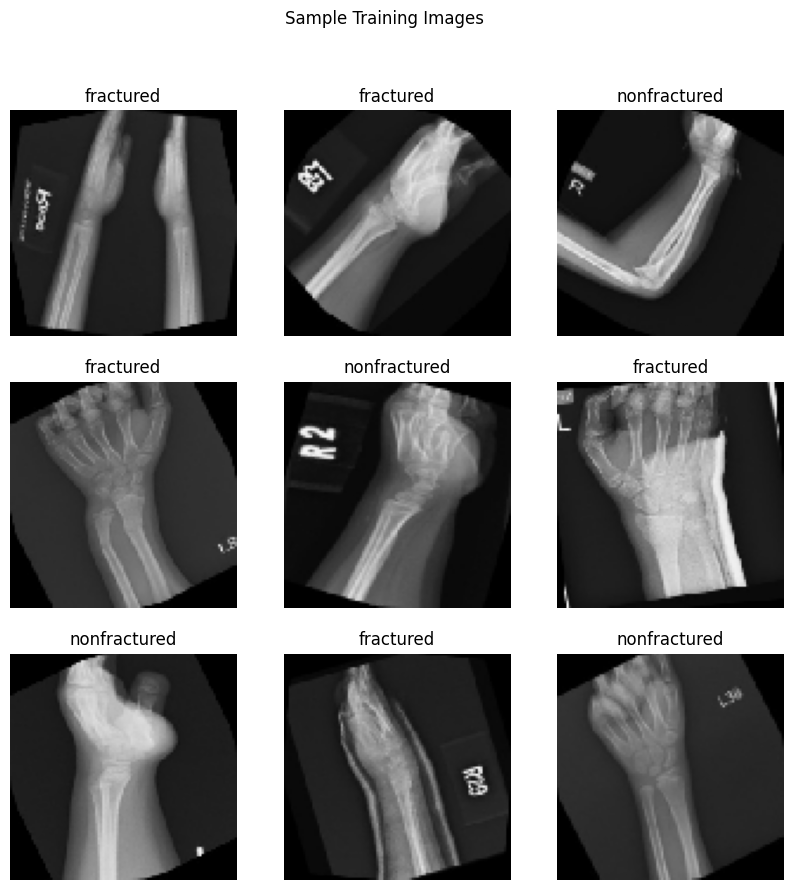

In [ ]:
#displaying sample training images
images, labels = next(train_ds)

#map numeric label to class names (0 to fractured, 1 to nonfractured)
class_map = {v: k for k, v in train_ds.class_indices.items()}

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1) #3x3 grid
    plt.imshow(images[i].squeeze(), cmap='gray') #display img
    label_idx = int(labels[i])  #getting label
    plt.title(f"{class_map[label_idx]}") #title for class name
    plt.axis("off")
plt.suptitle("Sample Training Images")
plt.show()


In [ ]:
#CNN model
model = Sequential([

    #layer 0: input layer
    InputLayer(input_shape=(96, 96, 3)), #input layer 96x96, RGB image

    #layer 1: convolutional layer 1
    Conv2D(32, (3, 3), activation='relu'), #32 filters, size 3x3. to detect simple patterns
    #layer 2: max pooling layer 1
    MaxPooling2D((2, 2)), #reduces img size with max size of 2x2

    #layer 3: convolutional layer 2
    Conv2D(64, (3, 3), activation='relu'), #64 filters, size 3x3. to detect slightly more complex patterns from prev layer's output
    #layer 4: max pooling layer 2
    MaxPooling2D((2, 2)), #reduces img size further by 2x2

    #layer 5: convolutional layer 3
    Conv2D(128, (3, 3), activation='relu'), #128 filters, size 3x3. to detect more complex patterns
    #layer 6: max pooling layer 3
    MaxPooling2D((2, 2)), #reduces img size even further by another 2x2

    #layer 7: flatten
    Flatten(),                      #flatten 3d layers to 1d list for dense layer
    #layer 8: dense
    Dense(128, activation='relu'),  #fully connected layer with 128 neurons
    #layer 9: dropout
    Dropout(0.5),                   #randomly turns off 50% neuron during training to prevent overfitting
    #layer 10: output layer
    Dense(1, activation='sigmoid')  #binary output using sigmoid (fractured or not)
])
#relu keeps strong signals n ignore weak ones

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
#compiling the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy']) #to track accuracy during training

#display summary of the model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,731,905 (6.61 MB)

 Trainable params: 1,731,905 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#training using training n validation sets for 10 epochs
history = model.fit(
    train_ds,
    validation_data=val_ds,  #to monitor model's performance after each epoch
    epochs=10
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 868ms/step - accuracy: 0.6975 - loss: 0.5603

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


297/297 ━━━━━━━━━━━━━━━━━━━━ 274s 914ms/step - accuracy: 0.6979 - loss: 0.5599 - val_accuracy: 0.8685 - val_loss: 0.3594
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 212s 713ms/step - accuracy: 0.9300 - loss: 0.1845 - val_accuracy: 0.9083 - val_loss: 0.2165
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 222s 747ms/step - accuracy: 0.9696 - loss: 0.0830 - val_accuracy: 0.9349 - val_loss: 0.1696
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 222s 748ms/step - accuracy: 0.9823 - loss: 0.0508 - val_accuracy: 0.9505 - val_loss: 0.1439
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 219s 739ms/step - accuracy: 0.9837 - loss: 0.0429 - val_accuracy: 0.9554 - val_loss: 0.1356
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 209s 704ms/step - accuracy: 0.9886 - loss: 0.0307 - val_accuracy: 0.9626 - val_loss: 0.1118
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 215s 723ms/step - accuracy: 0.9892 - loss: 0.0285 - val_accuracy: 0.9783 - val_loss: 0.0773
Epoch 8/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 257s 705ms/step - accuracy: 0.9922 - loss: 0.02

In [ ]:
#evaluation (accuracy)
loss, acc = model.evaluate(test_ds) #evaluate the model using test set
print(f"Test Accuracy: {acc:.4f}")
print(f"Test Loss: {loss:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 300s 20s/step - accuracy: 0.9745 - loss: 0.0244
Test Accuracy: 0.9802
Test Loss: 0.0338


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

#predict probabilities on test set
y_pred_probs = model.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype("int32")  #binary probability, either 0/1
y_true = test_ds.classes


#classification report, precision, recall, f-1 score
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(test_ds.class_indices.keys())))


16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 443ms/step

Classification Report:

              precision    recall  f1-score   support

   fractured       0.97      0.98      0.98       238
nonfractured       0.98      0.98      0.98       268

    accuracy                           0.98       506
   macro avg       0.98      0.98      0.98       506
weighted avg       0.98      0.98      0.98       506



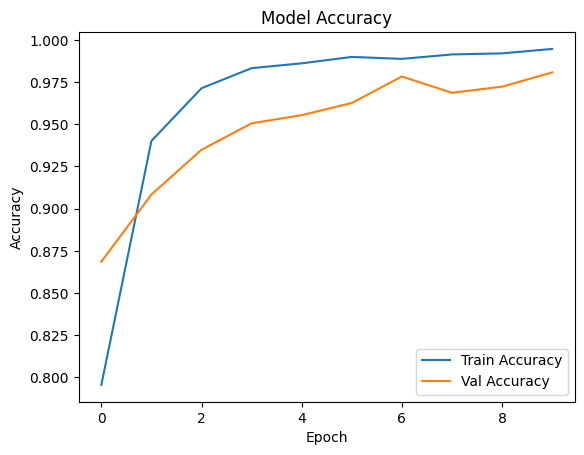

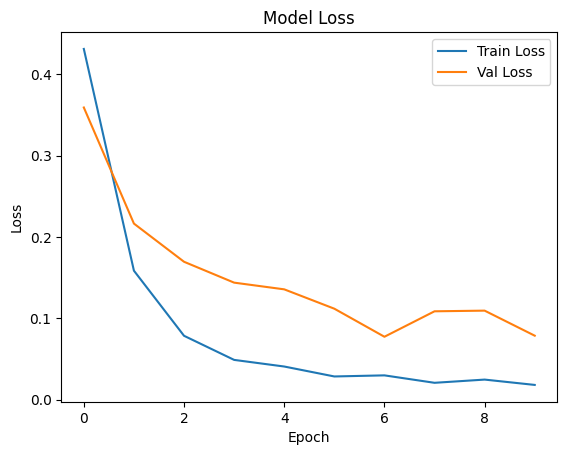

In [ ]:
#model's accuracy graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#model's loss graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

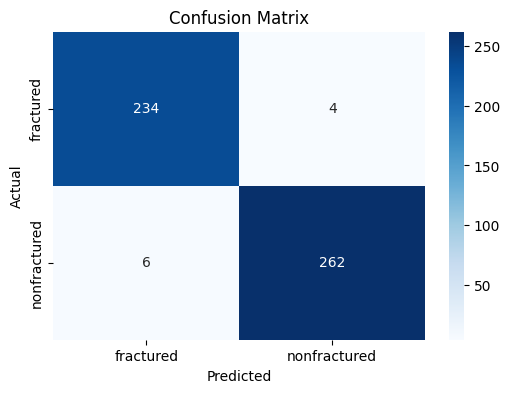

In [ ]:
#confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(test_ds.class_indices.keys()),
            yticklabels=list(test_ds.class_indices.keys()))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

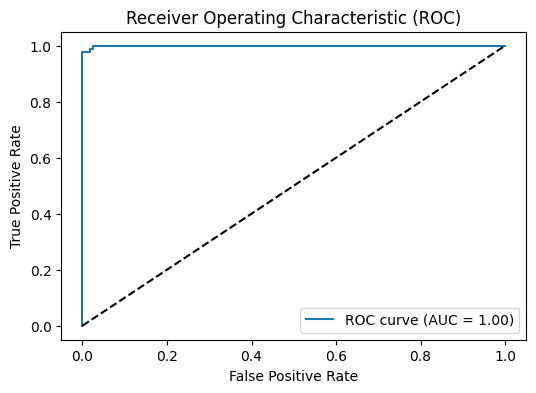

In [ ]:
#roc graph
from sklearn.metrics import roc_curve, auc

#getting roc values
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

#plotting roc curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Receiver Operating Characteristic (ROC)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()
